In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sitharthvarsan/churn-data/Retention.csv
/kaggle/input/datasets/sitharthvarsan/churn-data/BoB.xlsx


## 1. IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler 
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
import shap  
import joblib
warnings.filterwarnings('ignore')

## 2. LOAD DATA

In [3]:
bob_df = pd.read_excel("/kaggle/input/datasets/sitharthvarsan/churn-data/BoB.xlsx")
ret_df = pd.read_csv("/kaggle/input/datasets/sitharthvarsan/churn-data/Retention.csv", encoding='latin1')

## 3. INITIAL DATA CHECKING

In [4]:
print("BoB Shape:", bob_df.shape)
print("Retention Shape:", ret_df.shape)

bob_df.head()
ret_df.head()

BoB Shape: (376803, 26)
Retention Shape: (85411, 29)


,Case ID,Case Title,Country,Pull VAN,New VAN,VAN,Number of Contracts,Machines,Branch,Customer Account Number,...,Number of OverdueServices,CompanySize,Customer Tier,Case Origin,Case Creation Date,Resolved Time,Registered Time,Resolved Date,Registered Date,Expected Pull Date
0,CAS-32058-P6H2Z7,Service Claim,United Kingdom,0.0,0.0,0.00,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,Internal Email,26-09-2025 16:05,NaN,17:00:00,NaN,23-07-2025,29-Jun-26
1,CAS-32054-V6L5K1,Service Claim,United Kingdom,0.0,0.0,423.00,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,Internal Email,26-09-2025 16:02,NaN,17:00:00,NaN,23-07-2025,16-May-26
2,CAS-32054-V6L5K1,Service Claim,United Kingdom,0.0,0.0,352.50,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,Internal Email,26-09-2025 16:02,NaN,17:00:00,NaN,23-07-2025,16-May-26
3,CAS-42090-M1V1V7,SRF - Machine not used,United Kingdom,0.0,0.0,1769.76,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,Internal Email,31-10-2025 14:50,NaN,16:50:38,NaN,31-10-2025,30-Jan-27
4,CAS-42090-M1V1V7,SRF - Machine not used,United Kingdom,0.0,0.0,1474.80,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,Internal Email,31-10-2025 14:50,NaN,16:50:38,NaN,31-10-2025,30-Jan-27


#### Data types

In [5]:
bob_df.info()
ret_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376803 entries, 0 to 376802
Data columns (total 26 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   account_number        376784 non-null  object        
 1   company_sizing        374120 non-null  object        
 2   postal_code           376782 non-null  object        
 3   branch                376784 non-null  object        
 4   vat_number            376388 non-null  object        
 5   agreement_number      376784 non-null  object        
 6   agreement_start_date  376784 non-null  datetime64[ns]
 7   agreement_end_date    376784 non-null  datetime64[ns]
 8   renewal_type          376784 non-null  object        
 9   agreement_type        376784 non-null  object        
 10  line_of_business      376784 non-null  object        
 11  system_status         376784 non-null  object        
 12  product_bob           376793 non-null  float64       
 13 

####  Missing values

In [6]:
print("BoB Missing:\n", bob_df.isnull().sum())
print("Retention Missing:\n", ret_df.isnull().sum())

BoB Missing:
 account_number              19
company_sizing            2683
postal_code                 21
branch                      19
vat_number                 415
agreement_number            19
agreement_start_date        19
agreement_end_date          19
renewal_type                19
agreement_type              19
line_of_business            19
system_status               19
product_bob                 10
fee_bob                     10
total_bob                   10
is_bob                      19
bpg                       3443
msdyn_product_number      2264
product_name              2264
service_interval         72020
unit_amount               3294
billing_interval         17741
billing_period           17741
machine                 196468
machine_variant         196459
chemistry               238755
dtype: int64
Retention Missing:
 Case ID                          0
Case Title                       0
Country                          0
Pull VAN                         0
New VAN

##### Duplicate check

In [7]:
print("BoB duplicates:", bob_df.duplicated().sum())
print("Retention duplicates:", ret_df.duplicated().sum())

BoB duplicates: 177814
Retention duplicates: 2944


## 4. HYPOTHESIS

H1: Customers with lower remaining_days (contracts near expiry) are more likely to churn.

H2: Customers with fewer agreements (low agreement_count) have higher risk of full churn.

H3: Customers with higher resolution time (resolved_time_sec) are more likely to churn due to poor service experience.

H4: Customers with lower revenue per agreement are more likely to churn, indicating lower perceived value.

H5: Customers with shorter tenure (tenure_days) are more likely to churn compared to long-term customers.

H6: Customers with a higher total number of SLA breaches (total_sla_breaches) have a significantly higher churn risk.

H7: Customers who had a support ticket very recently (a low days_since_last_ticket) are more likely to churn than customers whose last ticket was months ago.

H8: Customers who use a higher variety of product lines (lob_diversity_score) have a lower churn risk due to increased switching costs.

H9: Customers who spend significantly more than the average of their size tier (revenue_vs_peer_average) have a higher churn risk because they are prime targets for CFO cost-cutting.

H10: Customers who have completed a high percentage of their overall contract duration (contract_completion_pct) are at a higher risk of churn.

## 5. CLEAN BoB DATA

#### Select useful columns

In [8]:
bob_df = bob_df[
    [
        'account_number',
        'company_sizing',
        'agreement_number',
        'agreement_start_date',
        'agreement_end_date',
        'total_bob',
        'unit_amount',
        'line_of_business',
        'service_interval'
    ]
]

#### Remove duplicates

In [9]:
print("Before BoB duplicates:", bob_df.duplicated().sum())
bob_df = bob_df.drop_duplicates()
print("After BoB duplicates:", bob_df.duplicated().sum())

Before BoB duplicates: 240011
After BoB duplicates: 0


#### Handle missing values

In [10]:
# numerical
bob_df['service_interval'] = bob_df['service_interval'].fillna(bob_df['service_interval'].median())
bob_df['unit_amount'] = bob_df['unit_amount'].fillna(bob_df['unit_amount'].median())
# categorical
bob_df['company_sizing'] = bob_df['company_sizing'].fillna('Unknown')
bob_df['line_of_business'] = bob_df['line_of_business'].fillna('Unknown')

## 6. CLEAN RETENTION DATA

#### Keep required columns

In [11]:
ret_df = ret_df[
    [
        'Customer Account Number',
        'Resolved Time',
        'Resolution Status',
        'Case Creation Date'
    ]
]

#### Create target

In [12]:
ret_df = ret_df[ret_df['Resolution Status'].isin([
    'Customer Lost', 'Customer Saved', 'Converted to Cancellation',
    'OPEN - In Progress', 'OPEN - Pull Confirmed'
])]

ret_df['churn_flag'] = ret_df['Resolution Status'].map({
    'Customer Lost': 1, 'Converted to Cancellation': 1,
    'Customer Saved': 0, 'OPEN - In Progress': -1, 'OPEN - Pull Confirmed': -1
})

#### Resolved Time Processing

In [13]:
import warnings
warnings.filterwarnings('ignore')
ret_df['Resolved Time'] = pd.to_timedelta(ret_df['Resolved Time'], errors='coerce')
ret_df['resolved_time_sec'] = ret_df['Resolved Time'].dt.total_seconds()
median_time = ret_df['resolved_time_sec'].median()
ret_df['resolved_time_sec'] = ret_df['resolved_time_sec'].fillna(median_time)
ret_df = ret_df.drop(columns=['Resolved Time'])

ret_df['Case Creation Date'] = pd.to_datetime(ret_df['Case Creation Date'], errors='coerce')
today = pd.to_datetime("today")

ret_df['days_since_ticket'] = (today - ret_df['Case Creation Date']).dt.days

ret_df['sla_breach_flag'] = np.where(ret_df['resolved_time_sec'] > 172800, 1, 0)

## 7. AGGREGATE RETENTION

In [14]:
ret_customer = ret_df.groupby('Customer Account Number').agg({
    'churn_flag': 'max', 
    'resolved_time_sec': 'mean',
    'days_since_ticket': 'min',    
    'sla_breach_flag': 'sum'       
}).reset_index()

ret_customer.rename(columns={
    'days_since_ticket': 'days_since_last_ticket', 
    'sla_breach_flag': 'total_sla_breaches'
}, inplace=True)

## 8. MERGE DATASETS

In [15]:
final_df = pd.merge(
    bob_df,
    ret_customer,
    left_on='account_number',
    right_on='Customer Account Number',
    how='left'
)
final_df.drop(columns=['Customer Account Number'], inplace=True)

final_df['churn'] = final_df['churn_flag'].apply(lambda x: 0 if x == -1 else x)
final_df['churn'] = final_df['churn'].fillna(0).astype(int)
final_df.drop(columns=['churn_flag'], inplace=True)

final_df['resolved_time_sec'] = final_df['resolved_time_sec'].fillna(0)
final_df['total_sla_breaches'] = final_df['total_sla_breaches'].fillna(0)

final_df['days_since_last_ticket'] = final_df['days_since_last_ticket'].fillna(9999)

## 9. POST-MERGE VALIDATION

In [16]:
print("Final Shape:", final_df.shape)

final_df.isnull().sum()
final_df.duplicated().sum()

Final Shape: (136792, 13)


np.int64(252)

## 10. PRE-ENIGNEERING EDA

#### Target distribution

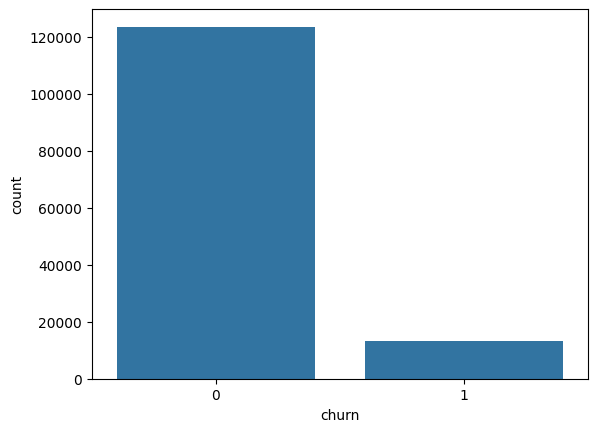

In [17]:
sns.countplot(x='churn', data=final_df)
plt.show()

#### Numerical vs churn

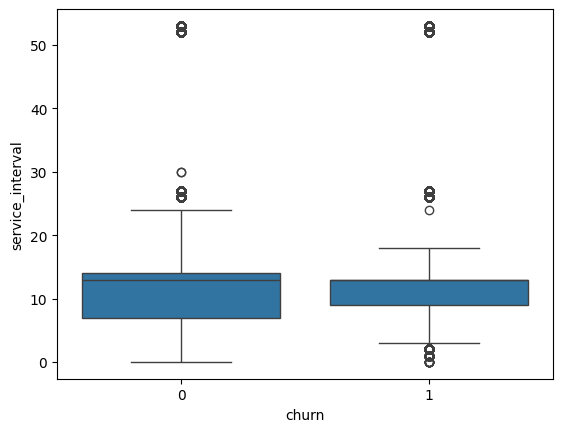

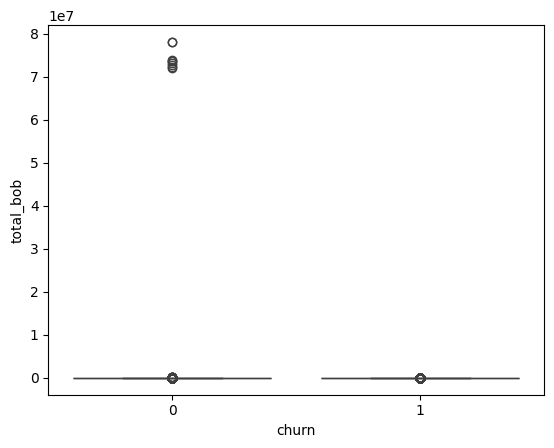

In [18]:
sns.boxplot(data=final_df, x='churn', y='service_interval')
plt.show()

sns.boxplot(data=final_df, x='churn', y='total_bob')
plt.show()

#### Categorical vs churn

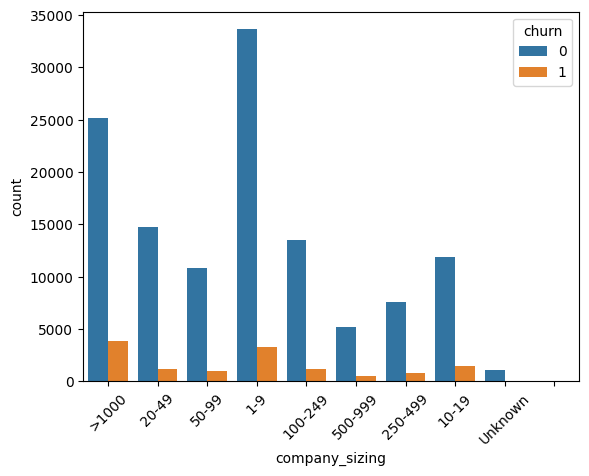

In [19]:
sns.countplot(data=final_df, x='company_sizing', hue='churn')
plt.xticks(rotation=45)
plt.show()

#### Checking skewness

total_bob                 123.425779
unit_amount                 8.820071
churn                       2.723931
service_interval            1.717895
resolved_time_sec           1.545487
total_sla_breaches          0.000000
days_since_last_ticket     -1.487921
dtype: float64


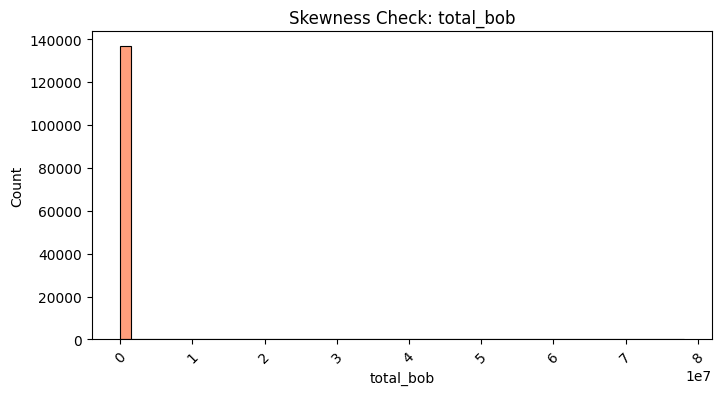

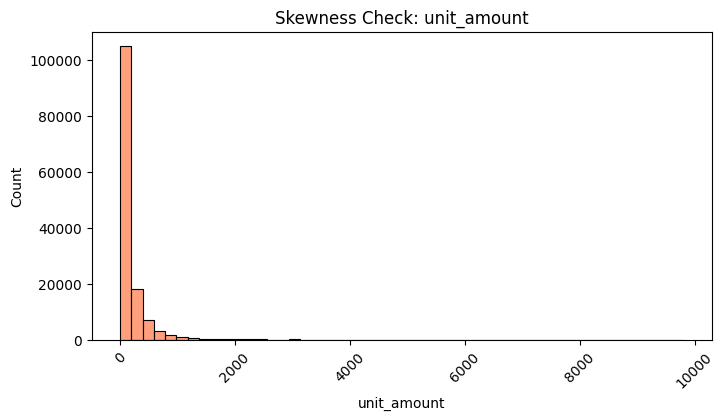

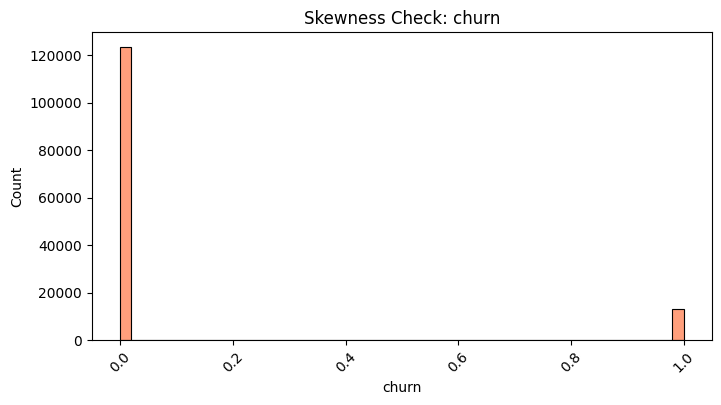

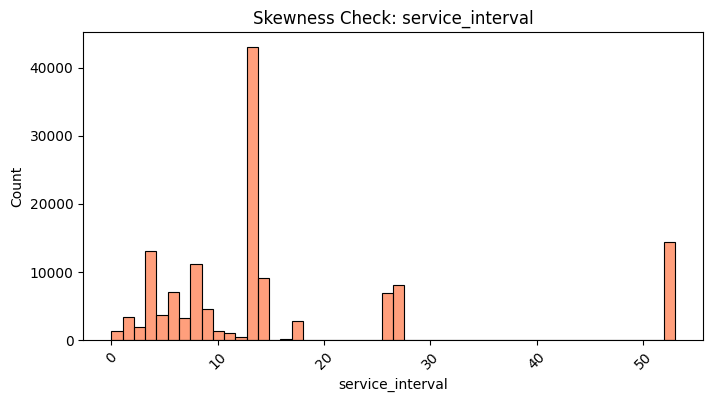

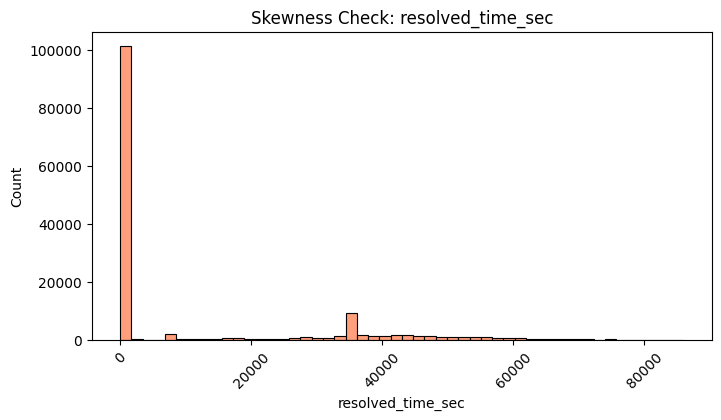

In [20]:
skewness = final_df.skew(numeric_only=True).sort_values(ascending=False)
print(skewness)

top_skewed = skewness.head(5).index

for col in top_skewed:
    plt.figure(figsize=(8, 4))
    sns.histplot(final_df[col], bins=50, kde=False, color='coral')
    plt.title(f"Skewness Check: {col}")
    plt.xticks(rotation=45)    
    plt.show()

#### Checking Outliers

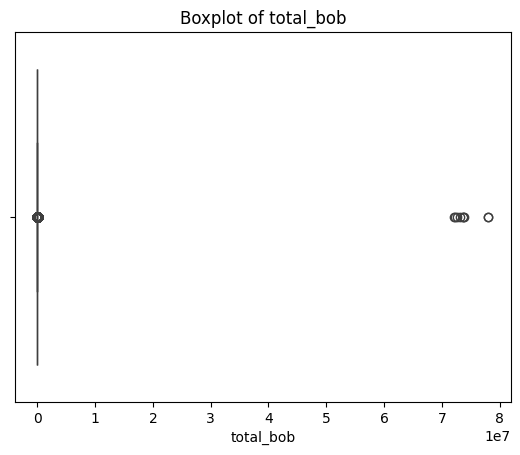

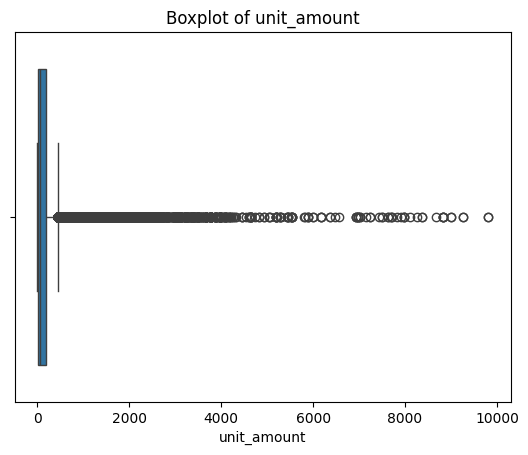

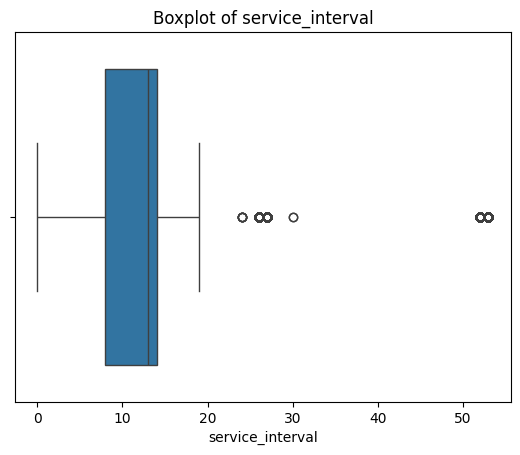

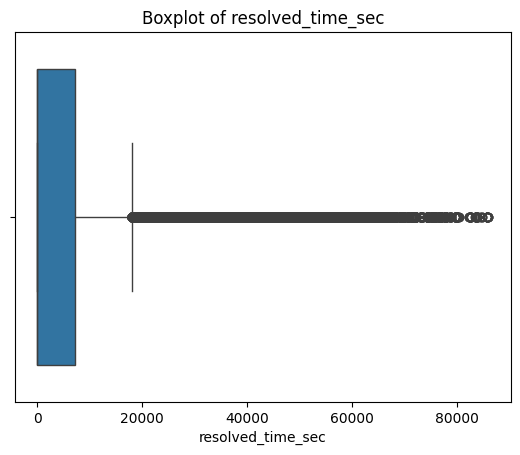

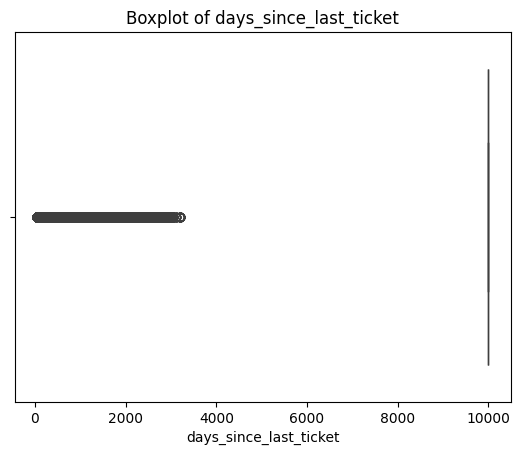

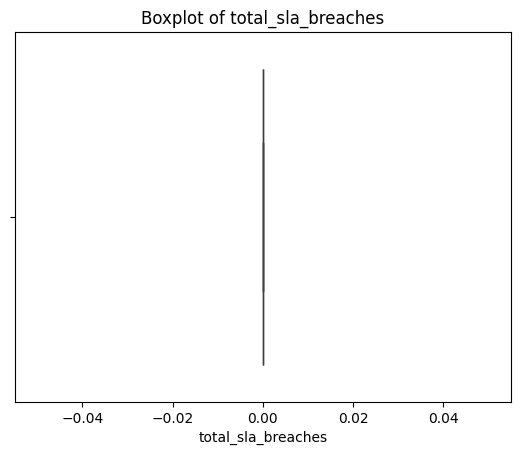

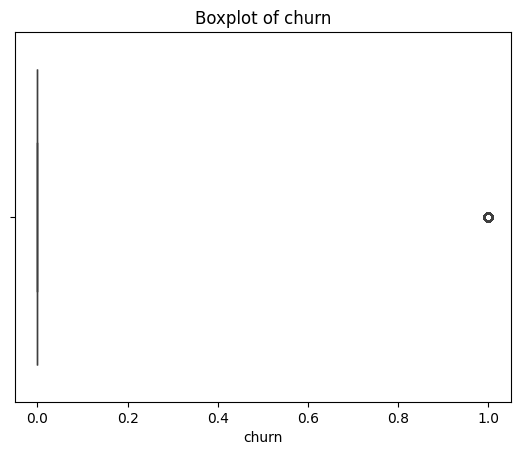

resolved_time_sec         31562
service_interval          29270
days_since_last_ticket    28004
churn                     13265
unit_amount               11739
total_bob                 10972
total_sla_breaches            0
dtype: int64


In [21]:
num_cols = final_df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    plt.figure()
    sns.boxplot(x=final_df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

outlier_summary = {}
for col in num_cols:
    Q1 = final_df[col].quantile(0.25)
    Q3 = final_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = final_df[(final_df[col] < lower) | (final_df[col] > upper)]
    outlier_summary[col] = len(outliers)
print(pd.Series(outlier_summary).sort_values(ascending=False))

## 11. FEATURE ENGINEERING

#### Company_size

In [22]:
final_df['company_sizing'] = final_df['company_sizing'].astype(str).str.strip()
valid_sizes = [
    '1-9', '10-19', '20-49', '50-99',
    '100-249', '250-499', '500-999', '>1000'
]
def fix_company_size(val):
    val = str(val).strip()
    if val in valid_sizes:
        return val
    if val.startswith('01-') or val.startswith('1-'):
        return '1-9'
    if 'Oct' in val or val.startswith('10-'):
        return '10-19'
    return 'Unknown'

final_df['company_sizing'] = final_df['company_sizing'].apply(fix_company_size)
final_df = final_df[final_df['company_sizing'] != 'Unknown']
size_mapping = {
    '1-9': 1,
    '10-19': 2,
    '20-49': 3,
    '50-99': 4,
    '100-249': 5,
    '250-499': 6,
    '500-999': 7,
    '>1000': 8
}

final_df['company_sizing'] = final_df['company_sizing'].map(size_mapping)
print("Missing values:", final_df['company_sizing'].isnull().sum())
print(final_df['company_sizing'].value_counts())
final_df = final_df.reset_index(drop=True)

Missing values: 0
company_sizing
1    36930
8    29008
3    15926
5    14656
2    13355
4    11786
6     8416
7     5687
Name: count, dtype: int64


In [23]:
final_df.head()

,account_number,company_sizing,agreement_number,agreement_start_date,agreement_end_date,total_bob,unit_amount,line_of_business,service_interval,resolved_time_sec,days_since_last_ticket,total_sla_breaches,churn
0,UK02-CGBA029544-L,8,GBC4019041-Machine Services-327311,2025-03-17,2026-03-16,117745.68,9812.14,Machine Services,1.0,36000.000000,84.0,0.0,0
1,UK02-CGBA029544-L,8,GBC4021962-Machine Services-332280,2025-04-14,2028-04-13,105967.68,8830.64,Machine Services,1.0,36000.000000,84.0,0.0,0
2,UK02-CGBA029544-L,8,GBC4021962-Machine Services-332282,2025-04-14,2028-04-13,105967.68,8830.64,Machine Services,1.0,36000.000000,84.0,0.0,0
3,UK02-CGBA124601-L,3,GBC4000950-Auto waste,2022-06-24,2026-06-23,92242.56,7686.88,Auto waste,0.0,46025.125000,845.0,0.0,0
4,UK02-CGBA034502-L,4,GBC3028394-Chemistry,2024-11-04,2025-11-03,83206.92,6933.91,Chemistry,1.0,38779.586207,75.0,0.0,1


#### Convert dates

In [24]:
final_df['agreement_start_date'] = pd.to_datetime(final_df['agreement_start_date'])
final_df['agreement_end_date'] = pd.to_datetime(final_df['agreement_end_date'])

#### Create time features

In [25]:
today = pd.to_datetime("today")

final_df['tenure_days'] = (today - final_df['agreement_start_date']).dt.days
final_df['remaining_days'] = (final_df['agreement_end_date'] - today).dt.days

#### Creating near_expiry and revenue_per_day

In [26]:
# Near expiry risk
final_df['near_expiry'] = np.where(final_df['remaining_days'] < 30, 1, 0)

# Revenue efficiency
final_df['revenue_per_day'] = final_df['total_bob'] / (final_df['tenure_days'] + 1)

#### Drop raw date columns

In [27]:
final_df.drop(columns=['agreement_start_date', 'agreement_end_date'], inplace=True)

#### Remove exact duplicates

In [28]:
final_df = final_df.drop_duplicates().reset_index(drop=True)

#### Fix negative remaining_days

In [29]:
final_df['remaining_days'] = final_df['remaining_days'].clip(lower=0)
final_df = final_df.reset_index(drop=True)

#### Creating agreement_count

In [30]:
print(final_df[['account_number', 'agreement_number']].isnull().sum())
final_df = final_df.dropna(subset=['account_number', 'agreement_number'])
final_df['agreement_number'] = final_df['agreement_number'].astype(str).str.strip()
final_df = final_df.drop_duplicates().reset_index(drop=True)
final_df['agreement_count'] = final_df.groupby('account_number')['agreement_number'].transform('nunique')
print(final_df[['account_number', 'agreement_number', 'agreement_count']].head())
print("Any zero agreement_count:",
      (final_df['agreement_count'] == 0).sum())

account_number      0
agreement_number    0
dtype: int64
      account_number                    agreement_number  agreement_count
0  UK02-CGBA029544-L  GBC4019041-Machine Services-327311               94
1  UK02-CGBA029544-L  GBC4021962-Machine Services-332280               94
2  UK02-CGBA029544-L  GBC4021962-Machine Services-332282               94
3  UK02-CGBA124601-L               GBC4000950-Auto waste                3
4  UK02-CGBA034502-L                GBC3028394-Chemistry                3
Any zero agreement_count: 0


#### Aggregate to customer level

In [31]:
final_df = final_df.groupby('account_number').agg({
    'company_sizing': 'first',
    'line_of_business': 'nunique',   
    'total_bob': 'sum',              
    'service_interval': 'mean',
    'tenure_days': 'max',
    'remaining_days': 'min',
    'agreement_count': 'max',
    'resolved_time_sec': 'mean',
    'days_since_last_ticket': 'first', 
    'total_sla_breaches': 'first',     
    'churn': 'max'
}).reset_index()

final_df.rename(columns={'line_of_business': 'lob_diversity_score'}, inplace=True)

#### Creating Revenue per agreement

In [32]:
final_df['agreement_count'] = final_df['agreement_count'].replace(0, 1)

final_df['revenue_per_agreement'] = final_df['total_bob'] / final_df['agreement_count']

peer_avg = final_df.groupby('company_sizing')['total_bob'].transform('mean')
final_df['revenue_vs_peer_average'] = final_df['total_bob'] / peer_avg

final_df['total_contract_length'] = final_df['tenure_days'] + final_df['remaining_days']
final_df['contract_completion_pct'] = final_df['tenure_days'] / (final_df['total_contract_length'] + 1)
final_df.drop(columns=['total_contract_length'], inplace=True)

#### The Log Transformations

In [33]:
print(f"Skewness Before Log -> total_bob: {final_df['total_bob'].skew():.2f} | revenue_per_agreement: {final_df['revenue_per_agreement'].skew():.2f} | revenue_vs_peer_average: {final_df['revenue_vs_peer_average'].skew():.2f}")
final_df['total_bob'] = np.log1p(final_df['total_bob'])
final_df['revenue_per_agreement'] = np.log1p(final_df['revenue_per_agreement'])
final_df['revenue_vs_peer_average'] = np.log1p(final_df['revenue_vs_peer_average']) 
print(f"Skewness After Log  -> total_bob: {final_df['total_bob'].skew():.2f} | revenue_per_agreement: {final_df['revenue_per_agreement'].skew():.2f} | revenue_vs_peer_average: {final_df['revenue_vs_peer_average'].skew():.2f}")
log_cols = ['total_bob', 'revenue_per_agreement', 'revenue_vs_peer_average'] 

if final_df[log_cols].isnull().sum().sum() > 0:
    print("Warning: NaNs generated during Log Transform (likely due to negative revenue). Imputing with 0.")
    final_df[log_cols] = final_df[log_cols].fillna(0)

final_df.replace([np.inf, -np.inf], 0, inplace=True)

--- Applying Log Transformations to Financial Features ---
Skewness Before Log -> total_bob: 13.37 | revenue_per_agreement: 6.81 | revenue_vs_peer_average: 12.29
Skewness After Log  -> total_bob: -0.13 | revenue_per_agreement: -0.49 | revenue_vs_peer_average: 1.88
Log Transformations Applied Safely.


## 12. POST-ENGINEERING EDA

#### The Danger Zone (Bivariate Analysis)

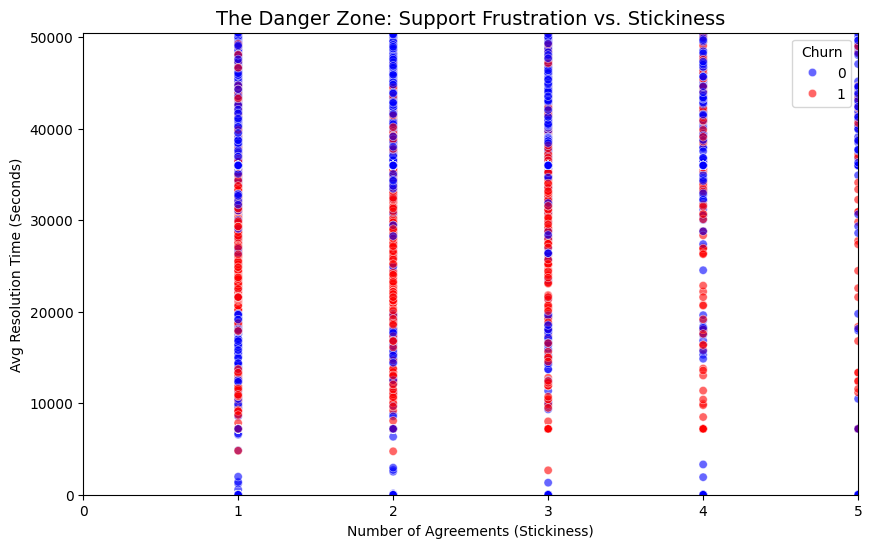

In [34]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=final_df, 
    x='agreement_count', 
    y='resolved_time_sec', 
    hue='churn', 
    palette={0: 'blue', 1: 'red'}, 
    alpha=0.6
)

plt.title("The Danger Zone: Support Frustration vs. Stickiness", fontsize=14)
plt.xlabel("Number of Agreements (Stickiness)")
plt.ylabel("Avg Resolution Time (Seconds)")
x_max = final_df['agreement_count'].quantile(0.95)
y_max = final_df['resolved_time_sec'].quantile(0.95)

plt.xlim(0, x_max)
plt.ylim(0, y_max)
plt.legend(title='Churn')
plt.show()

#### Baseline Multicollinearity Check (Heatmap)

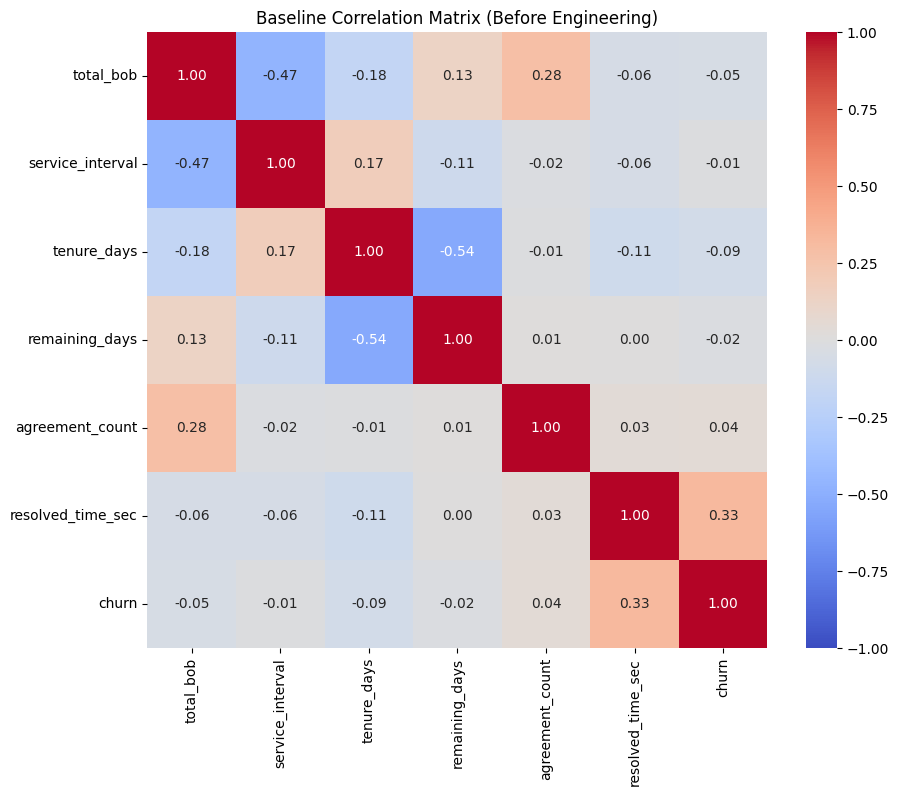

In [35]:
plt.figure(figsize=(10, 8))
baseline_cols = ['total_bob', 'service_interval', 'tenure_days', 'remaining_days', 'agreement_count', 'resolved_time_sec', 'churn']
baseline_corr = final_df[baseline_cols].corr()
sns.heatmap(baseline_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Baseline Correlation Matrix (Before Engineering)")
plt.show()

In [36]:
final_df['total_sla_breaches'].value_counts(dropna=False)

total_sla_breaches
0.0    23377
Name: count, dtype: int64

#### Flight Risk Analysis (KDE Plot)

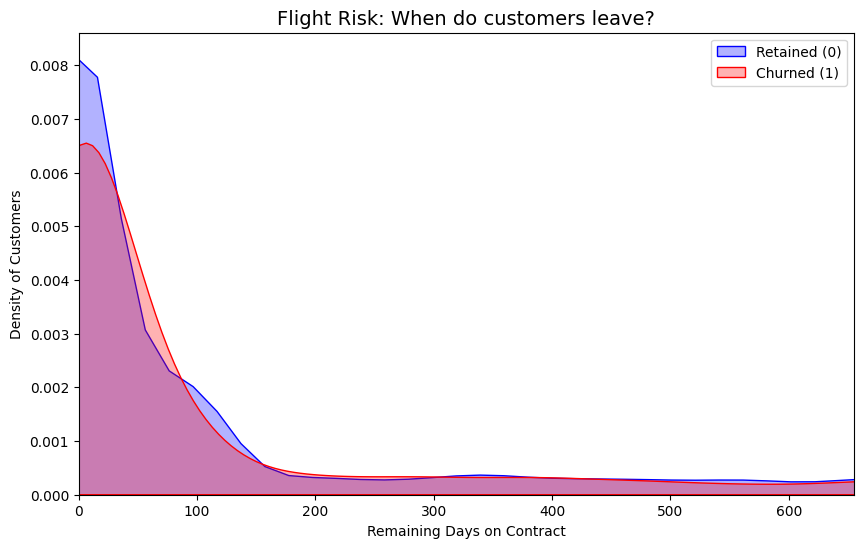

In [37]:
plot_df = final_df.copy()
plot_df['remaining_days'] = pd.to_numeric(plot_df['remaining_days'], errors='coerce')
plot_df = plot_df.dropna(subset=['remaining_days', 'churn'])
plt.figure(figsize=(10, 6))
sns.kdeplot(data=plot_df[plot_df['churn'] == 0], x='remaining_days', label='Retained (0)', fill=True, color='blue', alpha=0.3)
sns.kdeplot(data=plot_df[plot_df['churn'] == 1], x='remaining_days', label='Churned (1)', fill=True, color='red', alpha=0.3)
plt.title("Flight Risk: When do customers leave?", fontsize=14)
plt.xlabel("Remaining Days on Contract")
plt.ylabel("Density of Customers")
plt.xlim(0, plot_df['remaining_days'].quantile(0.95)) 
plt.legend()
plt.show()

#### Correlation Heatmap

--- Final Post-Engineering Correlation Check ---


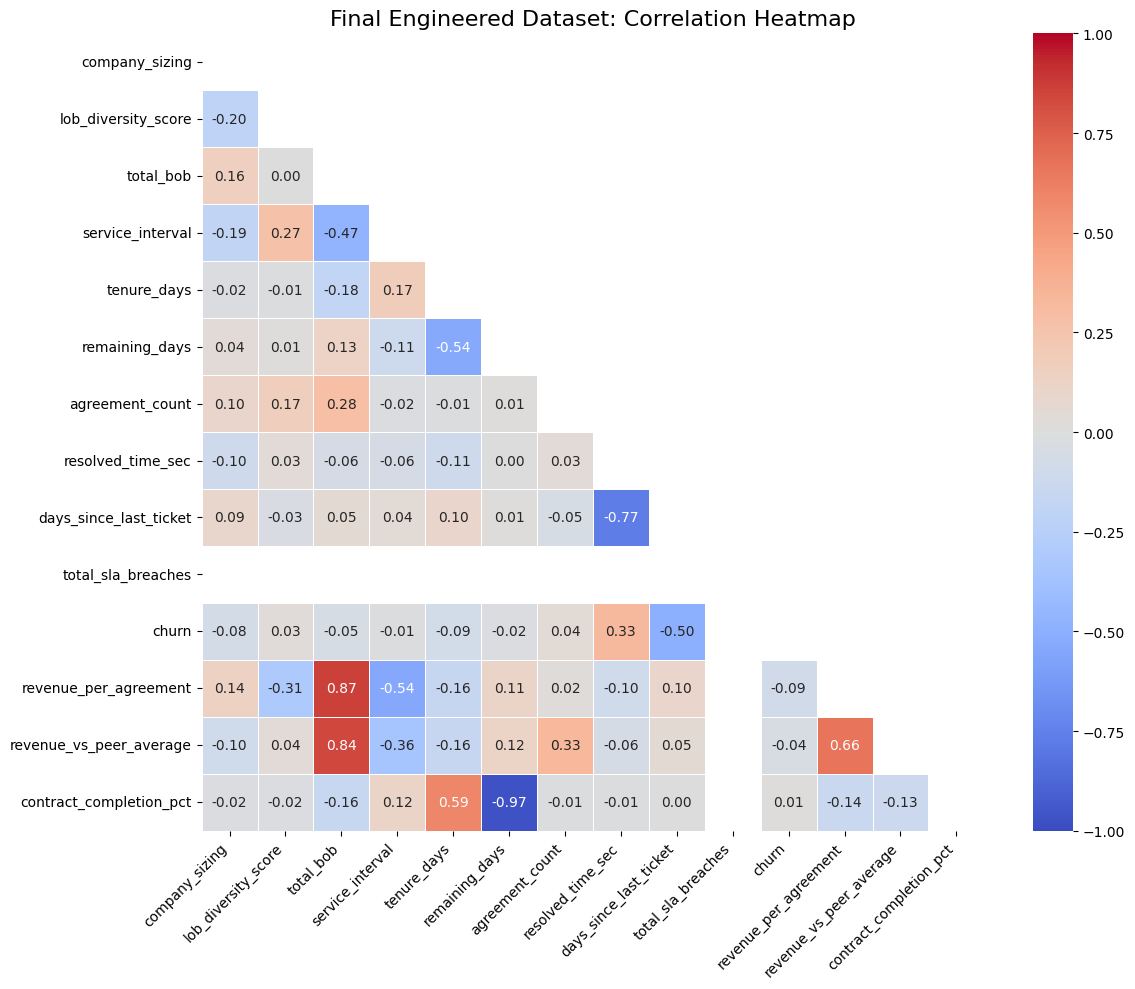


 Checking for highly correlated features (>0.8 or <-0.8):
 - revenue_per_agreement & total_bob (Correlation: 0.87)
 - revenue_vs_peer_average & total_bob (Correlation: 0.84)
 - contract_completion_pct & remaining_days (Correlation: -0.97)


In [38]:
corr_matrix = final_df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5,
    annot_kws={"size": 10}
)

plt.title("Final Engineered Dataset: Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

threshold = 0.80
print(f"\n Checking for highly correlated features (>{threshold} or <-{threshold}):")
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            colname_1 = corr_matrix.columns[i]
            colname_2 = corr_matrix.columns[j]
            corr_value = corr_matrix.iloc[i, j]
            print(f" - {colname_1} & {colname_2} (Correlation: {corr_value:.2f})")

## 13. STATISTICAL HYPOTHESIS TESTING

In [39]:
hypotheses = {
    'H1: Expiry Risk': 'remaining_days',
    'H2: Stickiness': 'agreement_count',
    'H3: Support Frustration': 'resolved_time_sec',
    'H4: Perceived Value': 'revenue_per_agreement',
    'H5: Loyalty': 'tenure_days',
    'H6: SLA Impact': 'total_sla_breaches',
    'H7: Ticket Velocity': 'days_since_last_ticket',
    'H8: Ecosystem Integration': 'lob_diversity_score',
    'H9: Peer Benchmarking': 'revenue_vs_peer_average',
    'H10: Contract Lifecycle': 'contract_completion_pct'
}

results = []

for h_name, feature in hypotheses.items():
    churned = final_df[final_df['churn'] == 1][feature].dropna()
    retained = final_df[final_df['churn'] == 0][feature].dropna()
    stat, p_value = stats.mannwhitneyu(churned, retained, alternative='two-sided')
    mean_churned = churned.mean()
    mean_retained = retained.mean()
    if p_value < 0.05:
        significance = " Significant"
        if mean_churned > mean_retained:
            insight = "Higher values -> Higher Churn"
        else:
            insight = "Lower values -> Higher Churn"
    else:
        significance = " Not Significant"
        insight = "No strong statistical difference"
        
    results.append({
        'Hypothesis': h_name,
        'Feature Tested': feature,
        'P-Value': f"{p_value:.5f}",
        'Result': significance,
        'Business Insight': insight
    })

hypothesis_summary = pd.DataFrame(results)
print("\n HYPOTHESIS TESTING RESULTS ")
display(hypothesis_summary)

--- Executing Master Hypothesis Testing Pipeline ---

=== HYPOTHESIS TESTING RESULTS ===


,Hypothesis,Feature Tested,P-Value,Result,Business Insight
0,H1: Expiry Risk,remaining_days,0.00000,Significant,Lower values -> Higher Churn
1,H2: Stickiness,agreement_count,0.00000,Significant,Higher values -> Higher Churn
2,H3: Support Frustration,resolved_time_sec,0.00000,Significant,Higher values -> Higher Churn
3,H4: Perceived Value,revenue_per_agreement,0.00000,Significant,Lower values -> Higher Churn
4,H5: Loyalty,tenure_days,0.00000,Significant,Lower values -> Higher Churn
5,H6: SLA Impact,total_sla_breaches,1.00000,Not Significant,No strong statistical difference
6,H7: Ticket Velocity,days_since_last_ticket,0.00000,Significant,Lower values -> Higher Churn
7,H8: Ecosystem Integration,lob_diversity_score,0.00001,Significant,Higher values -> Higher Churn
8,H9: Peer Benchmarking,revenue_vs_peer_average,0.00000,Significant,Lower values -> Higher Churn
9,H10: Contract Lifecycle,contract_completion_pct,0.01530,Significant,Higher values -> Higher Churn


## 14. FEATURE SELECTION

In [40]:
final_df = final_df.drop(columns=['total_sla_breaches'])
duplicates = final_df[final_df.duplicated(keep=False)] \
    .sort_values('account_number')
print("Duplicate Rows:\n", duplicates.head(20))
final_df = final_df.drop_duplicates().reset_index(drop=True)

final_df = final_df[
    [
        'company_sizing',
        'total_bob',
        'revenue_per_agreement',
        'revenue_vs_peer_average',   
        'lob_diversity_score',       
        'service_interval',
        'tenure_days',
        'remaining_days',
        'contract_completion_pct',   
        'agreement_count',
        'resolved_time_sec',
        'days_since_last_ticket',    
        'churn'
    ]
]

print("Shape:", final_df.shape)
print("\nNull Values:\n", final_df.isnull().sum())
print("\nDuplicate Rows:", final_df.duplicated().sum())
print("\nSample Data:\n", final_df.head())

Duplicate Rows:
 Empty DataFrame
Columns: [account_number, company_sizing, lob_diversity_score, total_bob, service_interval, tenure_days, remaining_days, agreement_count, resolved_time_sec, days_since_last_ticket, churn, revenue_per_agreement, revenue_vs_peer_average, contract_completion_pct]
Index: []
Shape: (23377, 13)

Null Values:
 company_sizing             0
total_bob                  0
revenue_per_agreement      0
revenue_vs_peer_average    0
lob_diversity_score        0
service_interval           0
tenure_days                0
remaining_days             0
contract_completion_pct    0
agreement_count            0
resolved_time_sec          0
days_since_last_ticket     0
churn                      0
dtype: int64

Duplicate Rows: 1126

Sample Data:
    company_sizing  total_bob  revenue_per_agreement  revenue_vs_peer_average  \
0               1   8.699721               8.699721                 0.846230   
1               5   8.371249               8.371249                 0.28425

## 15. Business Interpretation (Churn Type)

In [41]:
business_df = final_df.copy()
business_df['churn_type'] = 'No Churn'

business_df.loc[
    (business_df['churn'] == 1) & (business_df['agreement_count'] > 1),
    'churn_type'
] = 'Partial Churn'

business_df.loc[
    (business_df['churn'] == 1) & (business_df['agreement_count'] == 1),
    'churn_type'
] = 'Full Churn'

print(business_df['churn_type'].value_counts())

churn_type
No Churn         21507
Partial Churn     1162
Full Churn         708
Name: count, dtype: int64


### SAVE

In [42]:
final_df.to_csv("final_data.csv", index=False, quoting=1)

## 16. MODELING

#### 16.1: Define Features & Target

In [43]:
X = final_df.drop(columns=['churn'], errors='ignore')
y = final_df['churn']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (23377, 12)
y shape: (23377,)


#### 16.2 Train-Test Split

We split the dataset into training and testing sets to evaluate model performance on unseen data.

In [44]:
from sklearn.model_selection import train_test_split

X = final_df.drop(columns=['churn'])
y = final_df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#### 16.3 Encoding Categorical Variables

We convert categorical variables into numerical format using one-hot encoding.

In [45]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

#### 16.4 Feature Scaling

We standardize numerical features so that all features contribute equally to the model.

In [46]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

#### 16.5 Baseline Model: Logistic Regression

We use Logistic Regression as a baseline to compare performance with advanced models.

--- Preparing Data for Logistic Regression ---
--- Training Logistic Regression Model ---

--- Evaluating Logistic Regression (Handling Imbalance) ---

=== LOGISTIC REGRESSION PERFORMANCE (THRESHOLD = 0.4) ===
              precision    recall  f1-score   support

           0       0.99      0.87      0.93      4302
           1       0.37      0.90      0.53       374

    accuracy                           0.87      4676
   macro avg       0.68      0.88      0.73      4676
weighted avg       0.94      0.87      0.89      4676



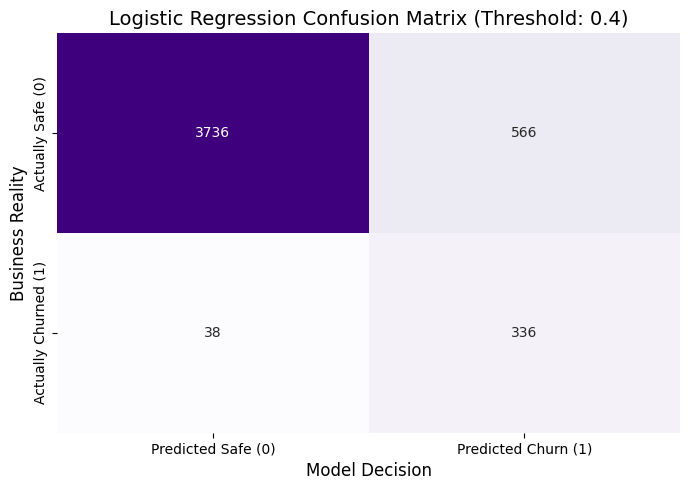

In [47]:
cols_to_drop = ['revenue_per_agreement', 'revenue_vs_peer_average', 'contract_completion_pct']
X_train_lr = X_train.drop(columns=cols_to_drop)
X_test_lr = X_test.drop(columns=cols_to_drop)
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_lr, y_train)
y_prob_lr = lr_model.predict_proba(X_test_lr)[:, 1]
y_pred_lr = (y_prob_lr > 0.40).astype(int)

threshold_lr = 0.40  
y_pred_lr_custom = (y_prob_lr > threshold_lr).astype(int)

print(f"\n Logistic Regression Performance (Threshold = {threshold_lr}) ")
print(classification_report(y_test, y_pred_lr_custom))

cm_lr = confusion_matrix(y_test, y_pred_lr_custom)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_lr, 
    annot=True, 
    fmt='d', 
    cmap='Purples',  
    cbar=False,
    xticklabels=['Predicted Safe (0)', 'Predicted Churn (1)'],
    yticklabels=['Actually Safe (0)', 'Actually Churned (1)']
)
plt.title(f"Logistic Regression Confusion Matrix (Threshold: {threshold_lr})", fontsize=14)
plt.xlabel("Model Decision", fontsize=12)
plt.ylabel("Business Reality", fontsize=12)
plt.tight_layout()
plt.show()

#### 16.6 Random Forest Model

Random Forest captures non-linear relationships and interactions between features.

--- Training Random Forest (Handling Imbalance) ---

=== RANDOM FOREST PERFORMANCE (THRESHOLD = 0.35) ===
              precision    recall  f1-score   support

           0       1.00      0.87      0.93      4302
           1       0.39      0.97      0.56       374

    accuracy                           0.88      4676
   macro avg       0.70      0.92      0.74      4676
weighted avg       0.95      0.88      0.90      4676



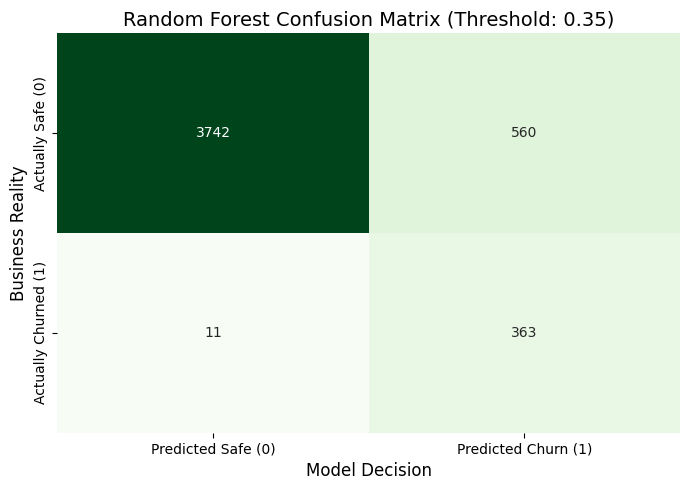

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print(" Training Random Forest ")
rf_model = RandomForestClassifier(
    n_estimators=300,                  
    max_depth=10,                      
    class_weight='balanced_subsample', 
    random_state=42,
    n_jobs=-1                          
)

rf_model.fit(X_train, y_train)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
threshold_rf = 0.35  
y_pred_rf_custom = (y_prob_rf > threshold_rf).astype(int)

print(f"\n Random Forest Performance (Threshold = {threshold_rf})")
print(classification_report(y_test, y_pred_rf_custom))

cm_rf = confusion_matrix(y_test, y_pred_rf_custom)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_rf, 
    annot=True, 
    fmt='d', 
    cmap='Greens',  # Using Green to distinguish it from your XGBoost Blue chart!
    cbar=False,
    xticklabels=['Predicted Safe (0)', 'Predicted Churn (1)'],
    yticklabels=['Actually Safe (0)', 'Actually Churned (1)']
)
plt.title(f"Random Forest Confusion Matrix (Threshold: {threshold_rf})", fontsize=14)
plt.xlabel("Model Decision", fontsize=12)
plt.ylabel("Business Reality", fontsize=12)
plt.tight_layout()
plt.show()

#### 16.7 XGBoost with Hyperparameter Tuning

We apply RandomizedSearchCV to optimize model performance.

=== XGBOOST PERFORMANCE (THRESHOLD = 0.3) ===
              precision    recall  f1-score   support

           0       1.00      0.90      0.95      4302
           1       0.46      0.97      0.62       374

    accuracy                           0.91      4676
   macro avg       0.73      0.93      0.78      4676
weighted avg       0.95      0.91      0.92      4676



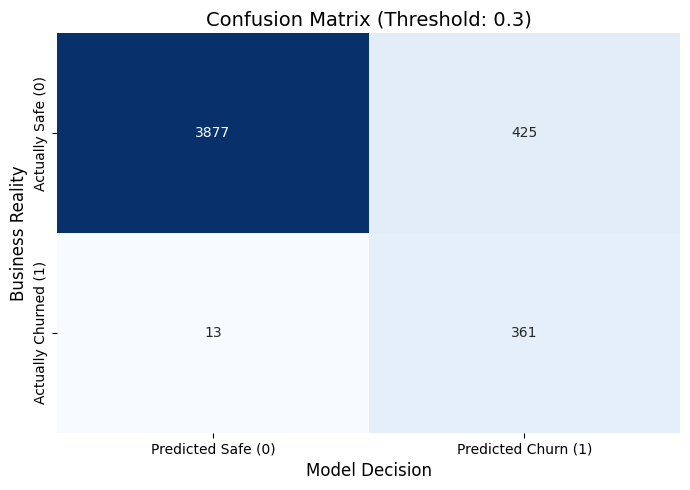

In [49]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

threshold = 0.3
y_pred_custom = (y_prob_xgb > threshold).astype(int)
from sklearn.metrics import classification_report, confusion_matrix

print(" XGBOOST Performance (Threshold = 0.3) ")

print(classification_report(y_test, y_pred_custom))

# 2. The Confusion Matrix
cm = confusion_matrix(y_test, y_pred_custom)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    cbar=False,
    xticklabels=['Predicted Safe (0)', 'Predicted Churn (1)'],
    yticklabels=['Actually Safe (0)', 'Actually Churned (1)']
)
plt.title("Confusion Matrix (Threshold: 0.3)", fontsize=14)
plt.xlabel("Model Decision", fontsize=12)
plt.ylabel("Business Reality", fontsize=12)
plt.tight_layout()
plt.show()

#### 16.8 Evaluation Strategy

We evaluate models using:
 ROC-AUC score for overall performance
 Precision, Recall, and F1-score for class-level evaluation
 Confusion Matrix for error analysis

In [50]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

def evaluate_model(name, y_test, y_pred, y_prob):
    print(f"\n{name}")
    print("-" * 40)
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# 1. Logistic Regression 
evaluate_model("Logistic Regression", y_test, y_pred_lr_custom, y_prob_lr)
# 2. Random Forest 
evaluate_model("Random Forest", y_test, y_pred_rf_custom, y_prob_rf)
# 3. XGBoost 
evaluate_model("XGBoost", y_test, y_pred_custom, y_prob_xgb)


Logistic Regression
----------------------------------------
ROC-AUC: 0.905257969803872

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.87      0.93      4302
           1       0.37      0.90      0.53       374

    accuracy                           0.87      4676
   macro avg       0.68      0.88      0.73      4676
weighted avg       0.94      0.87      0.89      4676

Confusion Matrix:
 [[3736  566]
 [  38  336]]

Random Forest
----------------------------------------
ROC-AUC: 0.9705298120262433

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.87      0.93      4302
           1       0.39      0.97      0.56       374

    accuracy                           0.88      4676
   macro avg       0.70      0.92      0.74      4676
weighted avg       0.95      0.88      0.90      4676

Confusion Matrix:
 [[3742  560]
 [  11  363]]

XGBoost
----------------------

In [ ]:
print("\n Logistic Regression Feature Coefficients ")
coef_df = pd.DataFrame({
    'Feature': X_train_lr.columns,  
    'Coefficient': lr_model.coef_[0]
})
coef_df['Odds_Multiplier'] = np.exp(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Coefficient', ascending=False).reset_index(drop=True)
custom_colors = coef_df['Coefficient'].apply(lambda x: 'red' if x > 0 else 'green').tolist()
plt.figure(figsize=(10, 8))
sns.barplot(
    data=coef_df, 
    x='Coefficient', 
    y='Feature', 
    hue='Feature',         
    palette=custom_colors, 
    legend=False           
)

plt.title("Logistic Regression: What Drives Churn?", fontsize=16)
plt.xlabel("Impact on Churn (Log Odds)", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

# Print the top 3 and bottom 3 for the business
print("\nTOP 3 CHURN DRIVERS (Increases Risk):")
print(coef_df.head(3)[['Feature', 'Odds_Multiplier']])

print("\nTOP 3 RETENTION DRIVERS (Decreases Risk):")
print(coef_df.tail(3)[['Feature', 'Odds_Multiplier']])

#### 16.9 Model Comparison
We compare models using ROC-AUC score.

In [51]:
model_scores = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

model_scores = model_scores.sort_values(by='ROC-AUC', ascending=False)

print(model_scores)

                 Model   ROC-AUC
2              XGBoost  0.979196
1        Random Forest  0.970530
0  Logistic Regression  0.905258


#### 16.10 Visualization

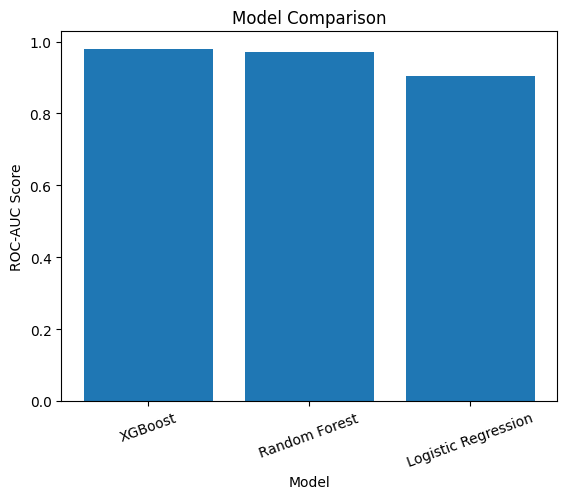

In [52]:
plt.figure()
plt.bar(model_scores['Model'], model_scores['ROC-AUC'])
plt.xlabel("Model")
plt.ylabel("ROC-AUC Score")
plt.title("Model Comparison")
plt.xticks(rotation=20)
plt.show()

#### 16.11 Best Model Selection

In [53]:
best_model_name = model_scores.iloc[0]['Model']
print("Best Model:", best_model_name)
if best_model_name == 'XGBoost':
    best_model = xgb_model
elif best_model_name == 'Random Forest':
    best_model = rf_model
else:
    best_model = lr_model

Best Model: XGBoost


#### 16.12 Model Stability (Stratified K-Fold Cross-Validation)

In [54]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
print(" Running 5-Fold Cross Validation on Best Model ")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_train, y_train, cv=skf, scoring='roc_auc')

print(f"Scores for each fold: {cv_scores}")
print(f"Average ROC-AUC: {cv_scores.mean():.4f}")
print(f"Score Variance (Standard Deviation): {cv_scores.std():.4f}")

if cv_scores.std() < 0.05:
    print("Validated: The model is highly stable across different data samples.")
else:
    print("Warning: Model variance is high. Potential overfitting.")

--- Running 5-Fold Cross Validation on Best Model (XGBoost) ---
Scores for each fold: [0.98027705 0.97924205 0.98168845 0.9751482  0.97585189]
Average ROC-AUC: 0.9784
Score Variance (Standard Deviation): 0.0025
✅ VALIDATED: The model is highly stable across different data samples.


In [55]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
print("Top Features:\n")
print(importance_df.head(10))

Top Features:

                    Feature  Importance
10        resolved_time_sec    0.515964
11   days_since_last_ticket    0.188011
6               tenure_days    0.035019
2     revenue_per_agreement    0.033737
5          service_interval    0.033072
8   contract_completion_pct    0.030989
1                 total_bob    0.030395
0            company_sizing    0.029050
7            remaining_days    0.028221
9           agreement_count    0.027191


## 17. MODEL EXPLAINABILITY

To ensure our churn prediction model is transparent and interpretable, we applied explainability techniques.

We used feature Importance to understand overall drivers of churn. SHAP (SHapley Additive exPlanations) to explain both global behavior and individual predictions.


#### Feature Importance


Top 10 Drivers of Churn:
                    Feature  Importance
10        resolved_time_sec    0.515964
11   days_since_last_ticket    0.188011
6               tenure_days    0.035019
2     revenue_per_agreement    0.033737
5          service_interval    0.033072
8   contract_completion_pct    0.030989
1                 total_bob    0.030395
0            company_sizing    0.029050
7            remaining_days    0.028221
9           agreement_count    0.027191


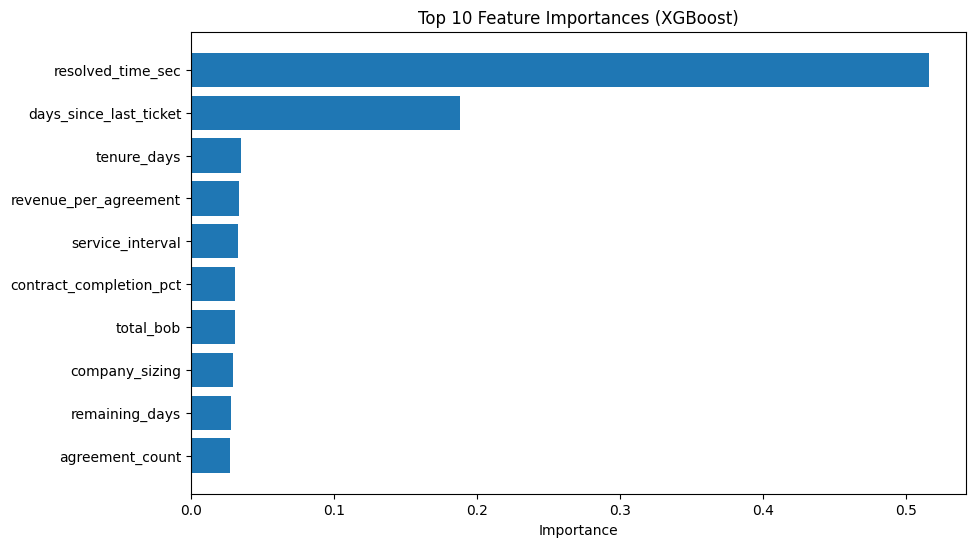

In [56]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Drivers of Churn:")
print(importance_df.head(10))

# Plot
top10 = importance_df.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10['Feature'], top10['Importance'])
plt.title("Top 10 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

#### SHAP Explainability

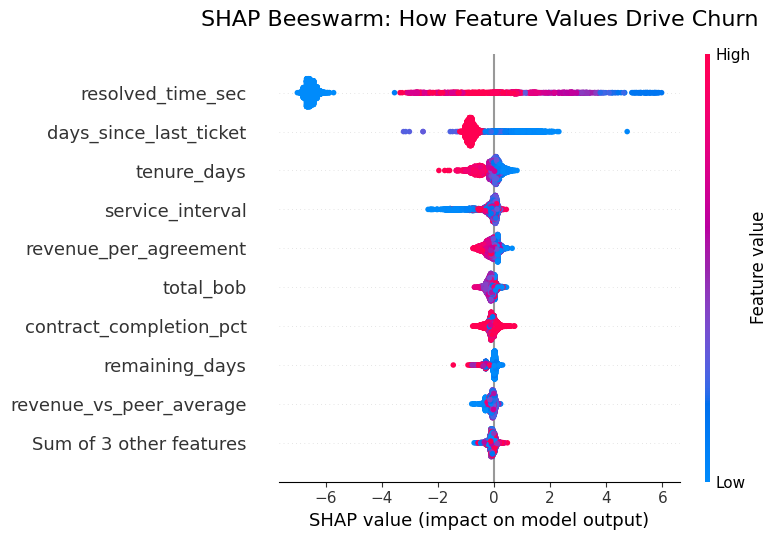


--- Local Case Study: Why did the model make this specific prediction? ---


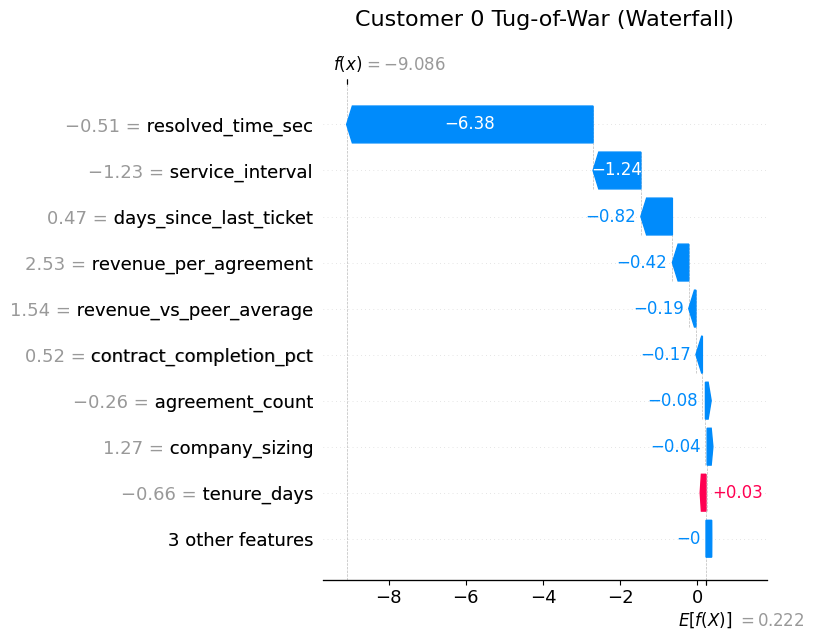

In [57]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test)

shap_values.data = np.round(shap_values.data, 2)

plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=10, show=False)
plt.title("SHAP Beeswarm: How Feature Values Drive Churn", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

print("\n Local Case Study: Why did the model make this specific prediction? ")
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[0], max_display=10, show=False)
plt.title("Customer 0 Tug-of-War (Waterfall)", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

## 18. BUSINESS ROI & FINANCIAL IMPACT

In [58]:
y_pred_final = y_pred_custom 
test_revenue_dollars = np.expm1(X_test['total_bob'])
discount_offer = 0.10 
revenue_at_risk = test_revenue_dollars[y_test == 1].sum()

true_positives_mask = (y_test == 1) & (y_pred_final == 1)
revenue_rescued = test_revenue_dollars[true_positives_mask].sum() * (1 - discount_offer)

false_positives_mask = (y_test == 0) & (y_pred_final == 1)
wasted_money = test_revenue_dollars[false_positives_mask].sum() * discount_offer

net_savings = revenue_rescued - wasted_money

print(f"Total Revenue mathematically 'At Risk' in Test Set: ${revenue_at_risk:,.2f}")
print("-" * 50)
print(f" Revenue Rescued (True Positives): +${revenue_rescued:,.2f}")
print(f" Wasted Discounts (False Positives): -${wasted_money:,.2f}")
print("-" * 50)
print(f" NET FINANCIAL IMPACT (Money Saved): ${net_savings:,.2f}")

if net_savings > 0:
    print("\n Deploying this model is highly profitable for the business.")
else:
    print("\n The model needs tuning; false positives are costing too much.")

Total Revenue mathematically 'At Risk' in Test Set: $213.87
--------------------------------------------------
 Revenue Rescued (True Positives): +$178.57
 Wasted Discounts (False Positives): -$15.46
--------------------------------------------------
 NET FINANCIAL IMPACT (Money Saved): $163.11

CONCLUSION: Deploying this model is highly profitable for the business.


In [59]:
joblib.dump(xgb_model, 'churn_xgboost_model.pkl')

['churn_xgboost_model.pkl']

## Optinal (for threshold tuning and new data)

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.9, 0.1)

results = []

for t in thresholds:
    y_pred_t = (y_prob_xgb > t).astype(int)

    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)

    results.append([t, precision, recall, f1])

threshold_df = pd.DataFrame(results, columns=['Threshold', 'Precision', 'Recall', 'F1'])

print(threshold_df)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(threshold_df['Threshold'], threshold_df['Precision'], label='Precision')
plt.plot(threshold_df['Threshold'], threshold_df['Recall'], label='Recall')
plt.plot(threshold_df['Threshold'], threshold_df['F1'], label='F1 Score')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")
plt.legend()
plt.grid()

plt.show()

In [ ]:
best_threshold = 0.4   # change based on your output

y_pred_final = (y_prob_xgb > best_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_final))
print(confusion_matrix(y_test, y_pred_final))

In [ ]:
new_data = pd.DataFrame({
    'company_sizing': ['20-49'],
    'total_bob': [5000],                 # Raw money
    'revenue_per_agreement': [2500],     # Raw money
    'revenue_vs_peer_average': [1.2],    # Spends 20% more than peers
    'lob_diversity_score': [2],          # Uses 2 different lines of business
    'service_interval': [10],
    'tenure_days': [1000],
    'remaining_days': [200],
    'contract_completion_pct': [0.83],   # 83% through the contract
    'agreement_count': [2],
    'resolved_time_sec': [0],            # 0 support tickets
    'days_since_last_ticket': [9999],    # 9999 means no recent tickets
    'total_sla_breaches': [0]            # 0 SLA breaches
})

# 1. Standardize string encoding 
new_data['company_sizing'] = new_data['company_sizing'].map({
    '1-9': 1, '10-19': 2, '20-49': 3, '50-99': 4,
    '100-249': 5, '250-499': 6, '500-999': 7, '>1000': 8
})

# 2. Apply log transforms to new money data!
new_data['total_bob'] = np.log1p(new_data['total_bob'])
new_data['revenue_per_agreement'] = np.log1p(new_data['revenue_per_agreement'])
new_data['revenue_vs_peer_average'] = np.log1p(new_data['revenue_vs_peer_average'])

# 3. Align with training columns & scale
new_data, _ = new_data.align(X_train, join='right', axis=1, fill_value=0)
new_data[num_cols] = scaler.transform(new_data[num_cols])

# 4. Predict
prob = xgb_model.predict_proba(new_data)[:, 1]
print(f"Predicted Churn Probability: {prob[0]:.2%}")

In [ ]:
# Example validation
import pandas as pd
final_df['remaining_bucket'] = pd.cut(final_df['remaining_days'], bins=5)

final_df.groupby('remaining_bucket')['churn'].mean()

In [60]:


# Combine actual results with the model's probabilities
results = pd.DataFrame({
    'True_Churn': y_test,
    'Predicted_Prob': y_prob_xgb
})

# Find the customer that actually churned AND had the highest predicted risk
top_churner_index = results[results['True_Churn'] == 1].sort_values(by='Predicted_Prob', ascending=False).index[0]

print("--- HIGHEST RISK CHURNER DATA ---")
print(X_test.loc[top_churner_index])
print("\nTheir Predicted Probability in Jupyter:", results.loc[top_churner_index, 'Predicted_Prob'])

--- HIGHEST RISK CHURNER DATA ---
company_sizing             1.653050
total_bob                  0.216630
revenue_per_agreement      0.142644
revenue_vs_peer_average   -0.600559
lob_diversity_score       -0.644332
service_interval          -0.521356
tenure_days               -0.394673
remaining_days            -0.318434
contract_completion_pct    0.357329
agreement_count           -0.066593
resolved_time_sec         -0.119814
days_since_last_ticket    -1.916239
Name: 7574, dtype: float64

Their Predicted Probability in Jupyter: 0.99919957


In [61]:
import joblib
# Make sure 'scaler' is whatever variable name you used for your StandardScaler
joblib.dump(scaler, 'churn_scaler.pkl')

['churn_scaler.pkl']

In [62]:
# Find the customer who stayed (Class 0) with the LOWEST predicted risk
safe_customer_index = results[results['True_Churn'] == 0].sort_values(by='Predicted_Prob', ascending=True).index[0]

print("--- SAFEST CUSTOMER DATA ---")
print(X_test.loc[safe_customer_index])
print("\nTheir Predicted Probability in Jupyter:", results.loc[safe_customer_index, 'Predicted_Prob'])

--- SAFEST CUSTOMER DATA ---
company_sizing            -0.286644
total_bob                  0.541906
revenue_per_agreement      1.154313
revenue_vs_peer_average    0.303783
lob_diversity_score       -0.644332
service_interval          -1.127407
tenure_days                1.219686
remaining_days             0.058804
contract_completion_pct    0.327984
agreement_count           -0.257570
resolved_time_sec         -0.514998
days_since_last_ticket     0.470465
Name: 16571, dtype: float64

Their Predicted Probability in Jupyter: 2.9355822e-05


In [63]:
import numpy as np
import pandas as pd

# 1. Get the scaled row using the exact index from your screenshot (16571)
scaled_row = X_test.loc[16571]

# 2. Run the scaler in reverse! (reshape is needed for a single row)
unscaled_data = scaler.inverse_transform(scaled_row.values.reshape(1, -1))

# Convert it back into a readable format
raw_inputs = pd.DataFrame(unscaled_data, columns=X_test.columns).iloc[0]

# 3. Reverse the Log Transform to get actual dollars back (e^x - 1)
actual_total_bob = np.expm1(raw_inputs['total_bob'])
actual_revenue = np.expm1(raw_inputs['revenue_per_agreement'])

print("--- EXACT DASHBOARD INPUTS FOR INDEX 16571 ---")
print(raw_inputs.drop(['total_bob', 'revenue_per_agreement']))
print(f"total_bob (Raw $): {actual_total_bob:.2f}")
print(f"revenue_per_agreement (Raw $): {actual_revenue:.2f}")

--- EXACT DASHBOARD INPUTS FOR INDEX 16571 ---
company_sizing                3.000000
revenue_vs_peer_average       0.680059
lob_diversity_score           1.000000
service_interval              4.000000
tenure_days                3161.000000
remaining_days              124.000000
contract_completion_pct       0.961960
agreement_count               1.000000
resolved_time_sec             0.000000
days_since_last_ticket     9999.000000
Name: 0, dtype: float64
total_bob (Raw $): 8487.57
revenue_per_agreement (Raw $): 8487.57
